# Exceedance Frequency Curve

In [1]:
import importlib
import pandas as pd
import xarray as xr
import numpy as np
import datetime as dt
import sys
import warnings
import math
import os
import cftime
from numpy import nan
from constants import *
from glob import glob
from timeit import default_timer as timer 

## Load and select hazard data

In [2]:
#Read historical hazard output of GCM 1: CNRM-CM6
bias_corr_hist_1 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_historical_1')
bias_corr_hist_2 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_historical_2')
bias_corr_hist_4 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_historical_4')

#Select the historical period between 1984 and 2014
bias_corr_hist_84_14_1 = bias_corr_hist_1.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_2 = bias_corr_hist_2.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_4 = bias_corr_hist_4.sel(valid_time=slice("1984-01-01", "2014-12-31"))

In [3]:
#Read future hazard output under SSP585 of GCM 1: CNRM-CM6
bias_corr_ssp585_1 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_ssp585_1')
bias_corr_ssp585_2 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_ssp585_2')
bias_corr_ssp585_4 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/bias_corr_ssp585_4')

#Select the future period between 2070 and 2100
bias_corr_ssp585_70_100_1 = bias_corr_ssp585_1.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_2 = bias_corr_ssp585_2.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_4 = bias_corr_ssp585_4.sel(valid_time=slice("2070-01-01", "2100-12-31"))

In [4]:
#Read historical hazard output of GCM 2: MPI-ESM1.2-LR
bias_corr_hist_1_MPI_ESM = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_historical_1')
bias_corr_hist_2_MPI_ESM = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_historical_2')
bias_corr_hist_4_MPI_ESM = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_historical_4')

#Select the historical period between 1984 and 2014
bias_corr_hist_84_14_1_MPI_ESM = bias_corr_hist_1_MPI_ESM.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_2_MPI_ESM = bias_corr_hist_2_MPI_ESM.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_4_MPI_ESM = bias_corr_hist_4_MPI_ESM.sel(valid_time=slice("1984-01-01", "2014-12-31"))

In [5]:
#Read future hazard output under SSP585 of GCM 2: MPI-ESM1.2-LR
bias_corr_ssp585_1_MPI_ESM  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_ssp585_1')
bias_corr_ssp585_2_MPI_ESM  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_ssp585_2')
bias_corr_ssp585_4_MPI_ESM  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MPI-ESM21-2-LR_bias_corr_ssp585_4')

#Select the future period between 2070 and 2100
bias_corr_ssp585_70_100_1_MPI_ESM  = bias_corr_ssp585_1_MPI_ESM.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_2_MPI_ESM  = bias_corr_ssp585_2_MPI_ESM .sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_4_MPI_ESM  = bias_corr_ssp585_4_MPI_ESM .sel(valid_time=slice("2070-01-01", "2100-12-31"))

In [6]:
#Read historical hazard output of GCM 3: MRI-ESM2.0
bias_corr_hist_1_MRI_ESM_2_0 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_historical_1')
bias_corr_hist_2_MRI_ESM_2_0= xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_historical_2')
bias_corr_hist_4_MRI_ESM_2_0 = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_historical_4')

#Select the historical period between 1984 and 2014
bias_corr_hist_84_14_1_MRI_ESM_2_0 = bias_corr_hist_1_MRI_ESM_2_0.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_2_MRI_ESM_2_0 = bias_corr_hist_2_MRI_ESM_2_0.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_4_MRI_ESM_2_0 = bias_corr_hist_4_MRI_ESM_2_0.sel(valid_time=slice("1984-01-01", "2014-12-31"))

In [7]:
#Read future hazard output under SSP585 of GCM 3: MRI-ESM2.0
bias_corr_ssp585_1_MRI_ESM_2_0  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_ssp585_1')
bias_corr_ssp585_2_MRI_ESM_2_0  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_ssp585_2')
bias_corr_ssp585_4_MRI_ESM_2_0  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/MRI-ESM-2-0_bias_corr_ssp585_4')

#Select the future period between 2070 and 2100
bias_corr_ssp585_70_100_1_MRI_ESM_2_0  = bias_corr_ssp585_1_MRI_ESM_2_0.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_2_MRI_ESM_2_0  = bias_corr_ssp585_2_MRI_ESM_2_0.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_4_MRI_ESM_2_0  = bias_corr_ssp585_4_MRI_ESM_2_0.sel(valid_time=slice("2070-01-01", "2100-12-31"))

In [8]:
#Read historical hazard output of GCM 4: EC-EARTH3
bias_corr_hist_1_EARTH = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_historical_1')
bias_corr_hist_2_EARTH = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_historical_3')
bias_corr_hist_4_EARTH  = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_historical_4')

#Select the historical period between 1984 and 2014
bias_corr_hist_84_14_1_EARTH  = bias_corr_hist_1_EARTH.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_2_EARTH  = bias_corr_hist_2_EARTH.sel(valid_time=slice("1984-01-01", "2014-12-31"))
bias_corr_hist_84_14_4_EARTH  = bias_corr_hist_4_EARTH.sel(valid_time=slice("1984-01-01", "2014-12-31"))

In [9]:
#Read future hazard output under SSP585 of GCM 4: EC-EARTH3
bias_corr_ssp585_1_EARTH   = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_ssp585_1')
bias_corr_ssp585_2_EARTH   = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_ssp585_3')
bias_corr_ssp585_4_EARTH   = xr.load_dataset('/Users/anne-sophiesimons/Documents/Data thesis/Bias Corrected data/België/EARTH_bias_corr_ssp585_4')

#Select the future period between 2070 and 2100
bias_corr_ssp585_70_100_1_EARTH   = bias_corr_ssp585_1_EARTH.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_2_EARTH   = bias_corr_ssp585_2_EARTH.sel(valid_time=slice("2070-01-01", "2100-12-31"))
bias_corr_ssp585_70_100_4_EARTH   = bias_corr_ssp585_4_EARTH.sel(valid_time=slice("2070-01-01", "2100-12-31"))

## Load and prepare exposure data

In [10]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import copy as cp
import pandas as pd
from scipy import sparse
import cartopy.crs as ccrs
from timeit import default_timer as timer
from os import mkdir, remove, rmdir

from climada.engine import Impact, ImpactCalc
from climada.entity import ImpactFunc,ImpactFuncSet

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
import logging
from climada.util.config import LOGGER
LOGGER.setLevel(logging.ERROR) 

##Load self-written, custom function definitions
from SL_bias_corr import *
from constants import *
from functions_projUncWS import *
idx = pd.IndexSlice

In [11]:
#Select the countries considered in this study
EU_countries = ['Belgium']

#Load LitPop metadata and read CSV document with all metadata of all countries
ltpop_info = pd.read_csv('/Users/anne-sophiesimons/Desktop/Climate change projections paper/data/_metadata_countries_v1_2.csv',sep=',')
#Filter the metadat of the selected countries
ctrs_metadata = ltpop_info[ltpop_info["country_name"].isin(EU_countries)][["country_name","region_id","iso3"]]
ctrs_regids = ctrs_metadata.region_id.tolist()

#All litpop region IDs for Belgium
BE_regids = ctrs_regids  

#load the LitPop data
from climada.entity import LitPop

#Select the values of the LitPop exponents to generate exposure layers
m, n = 1, 1
#The exposure resolution in arcseconds
res_exp = 30
#Threshold exposure value in USD
exp_thres = 1

#Generate LitPop exposure data for Belgium for the year 2010
exp_BE_2010 = LitPop.from_countries(BE_regids, res_arcsec=res_exp, exponents=[m, n], reference_year = 2010)

## Load and prepare vulnerability functions

In [12]:
##First impact function: Schwierz
#Import standard European windstorm impact function
from climada.entity.impact_funcs import storm_europe

#Load impact function based on Schwierz et al. (2010)
impFunc_schw = storm_europe.ImpfStormEurope.from_schwierz()

#Set the properties of the impact function 
impFunc_schw.id = 1 #Unique ID-number for the impact function
impFunc_schw.haz_type = 'WS' #Hazard type: wind storm
impFunc_schw.name = 'Sw2010' #Name of the impact function
impFunc_schw.check() #Check if all properties are correctly

In [13]:
##Second impact function: Cubic Excess over Threshold
#Implement impact function cubic excess over threshold from Klawa 2003
#Import the general ImpactFunc class
from climada.entity import ImpactFunc
#Make a new empty impact function
imp_fun_cub = ImpactFunc()
#Set the hazard type and name
imp_fun_cub.haz_type = 'WS'
imp_fun_cub.name = 'CubEOT'
#Provide unit of the hazard (wind) intensity
imp_fun_cub.intensity_unit = 'm/s'
#Define normalised wind intensities (0 to 1)
imp_fun_cub.intensity = np.linspace(0, 1, num=20)
#Define the damage function: damage increases cubically with intensity
imp_fun_cub.mdd = imp_fun_cub.intensity**3
#Add an extreme value: Above the extreme wind intensity then 100% damage
imp_fun_cub.intensity = np.append(imp_fun_cub.intensity, [40])
imp_fun_cub.mdd = np.append(imp_fun_cub.mdd, [1])
#Probability that there is damage is equal to 100% of all intensities
imp_fun_cub.paa = np.ones(imp_fun_cub.intensity.shape)

#Check if the all the attributes are set correctly
imp_fun_cub.id = 2
imp_fun_cub.check()

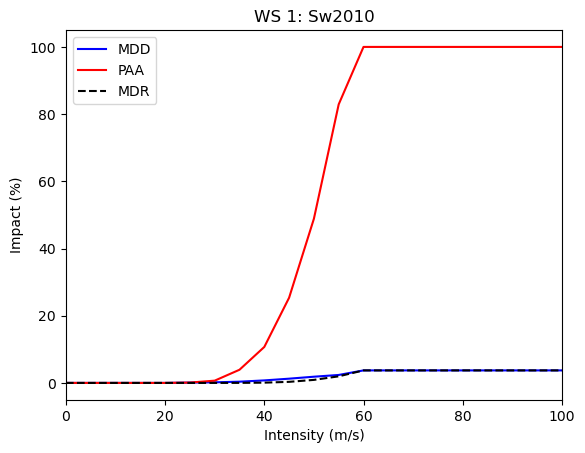

In [14]:
#Generate one impact function set containing all functions
from climada.entity import ImpactFuncSet
#Include the impact functions in the impact function set
#impf_list = [impFunc_schw, imp_fun_cub]
impf_list = [impFunc_schw]

#A list with function names and a dictionary linking names to IDs
impf_namelist = []
impf_dict = {}
#Create an empty impact function set
impf_set = ImpactFuncSet()

#Add each impact function to the set and store its name and ID
for impf in impf_list:
    impfname = impf.name
    impf_namelist.append(impfname)
    impf_dict[impfname] = impf.id
    impf_set.append(impf)
    impf_set.check() #Validate the impact function set

#Plot the impact functions
axs = impf_set.plot()

## Damage Calculation for each realization

In [57]:
pastname = 'historical'
timeres = 'day' #time dimension of the netcdf

#members
nmems = 0
stack = False #stack members or consider them separately

#impact functions
impf_dict = impf_dict #dictionary mapping impact functions names to their ids
impf_set = impf_set #impact function set
pp_func_dic = pp_func_dic #dict with the preprocessing functions for the impact functions

#regions
reglist = ['BEL']
#preprocessing
gst_fact = 1
qt = 0.98
cut= 100
mask_abs = 22.2
regrid = True
rg_res = 0.25 

#climada constants
haz_type = 'WS'
haz_id = 1
dist_th = 300 #const treshold in km for assign centroids

#Initiate DataFrame to save results
metrics = ['aai_agg',1,10,15, 25, 30] #Impact metrics to be computed, select aai_agg for Average Annual Damage, and integers for rps

iterables = [metrics,impf_dict.keys()]
col_idx1 = pd.MultiIndex.from_product(iterables,names=["metric","Impf"])
res_df = pd.DataFrame(columns=metrics,index=impf_dict.keys())

### GCM 1: CNRM-CM6 

In [16]:
#Load the exposure
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Use savehaz, saveimpcsv, saveimpmat to save hazards or/and imapcts.
saveimpmat = True
savestats = True
#Folder to store results
#results_folder= '/Users/anne-sophiesimons/Desktop/Climate change projections paper/results/'

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_1

#Get spatial, horizontal resolutions from CMIP6 data
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Regrid ERA5 data if requested
if regrid: #regrid era5
    latout = np.arange(min_lat,max_lat+rg_res,rg_res)
    lonout = np.arange(min_lon,max_lon+rg_res,rg_res)
    gust_era = gust_era.interp(latitude=latout,longitude=lonout, method='linear',kwargs={"fill_value": 'extrapolate'})

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)
    
    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_hist = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_hist.aai_agg
            else:
                impmet = imp_hist.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

##Compute Exceedance Frequency Curve
#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_hist_1 = imp_hist.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_hist_1 = res_df.astype(np.float64)
efc_hist_1

0.8051012079813518


ImpactFreqCurve(return_per=array([  1.        ,   3.02040816,   5.04081633,   7.06122449,
         9.08163265,  11.10204082,  13.12244898,  15.14285714,
        17.16326531,  19.18367347,  21.20408163,  23.2244898 ,
        25.24489796,  27.26530612,  29.28571429,  31.30612245,
        33.32653061,  35.34693878,  37.36734694,  39.3877551 ,
        41.40816327,  43.42857143,  45.44897959,  47.46938776,
        49.48979592,  51.51020408,  53.53061224,  55.55102041,
        57.57142857,  59.59183673,  61.6122449 ,  63.63265306,
        65.65306122,  67.67346939,  69.69387755,  71.71428571,
        73.73469388,  75.75510204,  77.7755102 ,  79.79591837,
        81.81632653,  83.83673469,  85.85714286,  87.87755102,
        89.89795918,  91.91836735,  93.93877551,  95.95918367,
        97.97959184, 100.        ]), impact=array([ 5052822.92462231, 14808567.53217215, 17166747.60878401,
       17784751.40472816, 18501810.01178233, 19029067.49499125,
       19386644.04995585, 19744220.60492046, 

In [18]:
#Load the exposure
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_2

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Regrid ERA5 data if requested
if regrid: #regrid era5
    latout = np.arange(min_lat,max_lat+rg_res,rg_res)
    lonout = np.arange(min_lon,max_lon+rg_res,rg_res)
    gust_era = gust_era.interp(latitude=latout,longitude=lonout, method='linear',kwargs={"fill_value": 'extrapolate'})

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)
    
    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_hist_2 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_hist_2.aai_agg
            else:
                impmet = imp_hist_2.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

# Return periods from 1 to 100 jaar
return_periods = np.linspace(1, 100, num=50)


#Calculate exceedance frequency curve
efc_hist_2 = imp_hist_2.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_hist_2 = res_df.astype(np.float64)
efc_hist_2

0.6707141249789856


ImpactFreqCurve(return_per=array([  1.        ,   3.02040816,   5.04081633,   7.06122449,
         9.08163265,  11.10204082,  13.12244898,  15.14285714,
        17.16326531,  19.18367347,  21.20408163,  23.2244898 ,
        25.24489796,  27.26530612,  29.28571429,  31.30612245,
        33.32653061,  35.34693878,  37.36734694,  39.3877551 ,
        41.40816327,  43.42857143,  45.44897959,  47.46938776,
        49.48979592,  51.51020408,  53.53061224,  55.55102041,
        57.57142857,  59.59183673,  61.6122449 ,  63.63265306,
        65.65306122,  67.67346939,  69.69387755,  71.71428571,
        73.73469388,  75.75510204,  77.7755102 ,  79.79591837,
        81.81632653,  83.83673469,  85.85714286,  87.87755102,
        89.89795918,  91.91836735,  93.93877551,  95.95918367,
        97.97959184, 100.        ]), impact=array([ 4959409.11127464, 17803329.77996806, 24923213.89440931,
       33170290.55268042, 40402147.06732131, 43535703.85605168,
       44563297.12066249, 45590890.38527329, 

In [19]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_4

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Regrid ERA5 data if requested
if regrid: #regrid era5
    latout = np.arange(min_lat,max_lat+rg_res,rg_res)
    lonout = np.arange(min_lon,max_lon+rg_res,rg_res)
    gust_era = gust_era.interp(latitude=latout,longitude=lonout, method='linear',kwargs={"fill_value": 'extrapolate'})

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_hist_4 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_hist_4.aai_agg
            else:
                impmet = imp_hist_4.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)


#Calculate exceedance frequency curve
efc_hist_4 = imp_hist_4.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_hist_4 = res_df.astype(np.float64)
efc_hist_4

0.5226507079787552


ImpactFreqCurve(return_per=array([  1.        ,   3.02040816,   5.04081633,   7.06122449,
         9.08163265,  11.10204082,  13.12244898,  15.14285714,
        17.16326531,  19.18367347,  21.20408163,  23.2244898 ,
        25.24489796,  27.26530612,  29.28571429,  31.30612245,
        33.32653061,  35.34693878,  37.36734694,  39.3877551 ,
        41.40816327,  43.42857143,  45.44897959,  47.46938776,
        49.48979592,  51.51020408,  53.53061224,  55.55102041,
        57.57142857,  59.59183673,  61.6122449 ,  63.63265306,
        65.65306122,  67.67346939,  69.69387755,  71.71428571,
        73.73469388,  75.75510204,  77.7755102 ,  79.79591837,
        81.81632653,  83.83673469,  85.85714286,  87.87755102,
        89.89795918,  91.91836735,  93.93877551,  95.95918367,
        97.97959184, 100.        ]), impact=array([ 2579091.27212872, 12039896.74364106, 17824129.15661938,
       18723020.94546413, 19633816.31997481, 20331429.02300907,
       20637193.02549825, 20942957.02798743, 

In [20]:
#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_1 

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Regrid ERA5 data if requested
if regrid: #regrid era5
    latout = np.arange(min_lat,max_lat+rg_res,rg_res)
    lonout = np.arange(min_lon,max_lon+rg_res,rg_res)
    gust_era = gust_era.interp(latitude=latout,longitude=lonout, method='linear',kwargs={"fill_value": 'extrapolate'})

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_585_1 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_585_1.aai_agg
            else:
                impmet = imp_585_1.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

# Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_585_1 = imp_585_1.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_ssp585_1 = res_df.astype(np.float64)
efc_585_1

1.3209770409739576


ImpactFreqCurve(return_per=array([  1.        ,   3.02040816,   5.04081633,   7.06122449,
         9.08163265,  11.10204082,  13.12244898,  15.14285714,
        17.16326531,  19.18367347,  21.20408163,  23.2244898 ,
        25.24489796,  27.26530612,  29.28571429,  31.30612245,
        33.32653061,  35.34693878,  37.36734694,  39.3877551 ,
        41.40816327,  43.42857143,  45.44897959,  47.46938776,
        49.48979592,  51.51020408,  53.53061224,  55.55102041,
        57.57142857,  59.59183673,  61.6122449 ,  63.63265306,
        65.65306122,  67.67346939,  69.69387755,  71.71428571,
        73.73469388,  75.75510204,  77.7755102 ,  79.79591837,
        81.81632653,  83.83673469,  85.85714286,  87.87755102,
        89.89795918,  91.91836735,  93.93877551,  95.95918367,
        97.97959184, 100.        ]), impact=array([1.04391610e+07, 2.71592620e+07, 3.44038239e+07, 4.65013126e+07,
       6.50094233e+07, 8.14931513e+07, 8.64926961e+07, 9.14922409e+07,
       9.49004365e+07, 9.796693

In [21]:
#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_2

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Regrid ERA5 data if requested
if regrid: #regrid era5
    latout = np.arange(min_lat,max_lat+rg_res,rg_res)
    lonout = np.arange(min_lon,max_lon+rg_res,rg_res)
    gust_era = gust_era.interp(latitude=latout,longitude=lonout, method='linear',kwargs={"fill_value": 'extrapolate'})

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)
    
    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_585_2 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_585_2.aai_agg
            else:
                impmet = imp_585_2.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve


#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_585_2 = imp_585_2.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_ssp585_2 = res_df.astype(np.float64)
efc_585_2

0.8614536669920199


ImpactFreqCurve(return_per=array([  1.        ,   3.02040816,   5.04081633,   7.06122449,
         9.08163265,  11.10204082,  13.12244898,  15.14285714,
        17.16326531,  19.18367347,  21.20408163,  23.2244898 ,
        25.24489796,  27.26530612,  29.28571429,  31.30612245,
        33.32653061,  35.34693878,  37.36734694,  39.3877551 ,
        41.40816327,  43.42857143,  45.44897959,  47.46938776,
        49.48979592,  51.51020408,  53.53061224,  55.55102041,
        57.57142857,  59.59183673,  61.6122449 ,  63.63265306,
        65.65306122,  67.67346939,  69.69387755,  71.71428571,
        73.73469388,  75.75510204,  77.7755102 ,  79.79591837,
        81.81632653,  83.83673469,  85.85714286,  87.87755102,
        89.89795918,  91.91836735,  93.93877551,  95.95918367,
        97.97959184, 100.        ]), impact=array([9.35568887e+06, 2.22255959e+07, 3.11523270e+07, 4.28985691e+07,
       6.55938511e+07, 8.80380553e+07, 1.03504320e+08, 1.18970585e+08,
       1.24541673e+08, 1.279880

In [22]:
#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_4

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Regrid ERA5 data if requested
if regrid: #regrid era5
    latout = np.arange(min_lat,max_lat+rg_res,rg_res)
    lonout = np.arange(min_lon,max_lon+rg_res,rg_res)
    gust_era = gust_era.interp(latitude=latout,longitude=lonout, method='linear',kwargs={"fill_value": 'extrapolate'})

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_585_4 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_585_4.aai_agg
            else:
                impmet = imp_585_4.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_585_4 = imp_585_4.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_ssp585_4 = res_df.astype(np.float64)
efc_585_4

0.4373139999806881


ImpactFreqCurve(return_per=array([  1.        ,   3.02040816,   5.04081633,   7.06122449,
         9.08163265,  11.10204082,  13.12244898,  15.14285714,
        17.16326531,  19.18367347,  21.20408163,  23.2244898 ,
        25.24489796,  27.26530612,  29.28571429,  31.30612245,
        33.32653061,  35.34693878,  37.36734694,  39.3877551 ,
        41.40816327,  43.42857143,  45.44897959,  47.46938776,
        49.48979592,  51.51020408,  53.53061224,  55.55102041,
        57.57142857,  59.59183673,  61.6122449 ,  63.63265306,
        65.65306122,  67.67346939,  69.69387755,  71.71428571,
        73.73469388,  75.75510204,  77.7755102 ,  79.79591837,
        81.81632653,  83.83673469,  85.85714286,  87.87755102,
        89.89795918,  91.91836735,  93.93877551,  95.95918367,
        97.97959184, 100.        ]), impact=array([ 2492668.22996123, 10520444.80614372, 12792957.83305922,
       13787656.46562192, 14941263.47957725, 16443446.07300493,
       18719671.31479966, 20995896.55659439, 

### GCM 2: MPI_ESM1.2

In [24]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_1_MPI_ESM

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)
    
    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MPI_hist_1 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MPI_hist_1.aai_agg
            else:
                impmet = imp_MPI_hist_1.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

# Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)


#Calculate exceedance frequency curve
efc_MPI_hist_1 = imp_MPI_hist_1.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MPI_hist_1= res_df.astype(np.float64)

res_df_MPI_hist_1

0.6390774580067955


,aai_agg,1,10,15,25,30
Sw2010,2.865420e+07,6.543502e+06,6.475246e+07,8.345981e+07,1.601317e+08,1.996321e+08


In [25]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_2_MPI_ESM

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MPI_hist_2 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MPI_hist_2.aai_agg
            else:
                impmet = imp_MPI_hist_2.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet


#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_MPI_hist_2 = imp_MPI_hist_2.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MPI_hist_2= res_df.astype(np.float64)

res_df_MPI_hist_2

0.7316600000485778


,aai_agg,1,10,15,25,30
Sw2010,2.292349e+07,4.859134e+06,3.993286e+07,8.943452e+07,1.074458e+08,1.141779e+08


In [26]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_4_MPI_ESM

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MPI_hist_4 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MPI_hist_4.aai_agg
            else:
                impmet = imp_MPI_hist_4.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)


#Calculate exceedance frequency curve
efc_MPI_hist_4 = imp_MPI_hist_4.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MPI_hist_4= res_df.astype(np.float64)

res_df_MPI_hist_4

0.60354791599093


,aai_agg,1,10,15,25,30
Sw2010,2.177954e+07,4.312772e+06,6.349005e+07,8.971993e+07,9.552624e+07,9.728352e+07


In [27]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_1_MPI_ESM

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)
    
    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MPI_SSP_1 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MPI_SSP_1.aai_agg
            else:
                impmet = imp_MPI_SSP_1.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)


#Calculate exceedance frequency curve
efc_MPI_hist_SSP_1 = imp_MPI_SSP_1.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MPI_SSP_1= res_df.astype(np.float64)

res_df_MPI_SSP_1

0.6884947079815902


,aai_agg,1,10,15,25,30
Sw2010,2.945764e+07,7.561510e+06,5.408836e+07,6.546416e+07,9.733266e+07,1.134736e+08


In [28]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_2_MPI_ESM

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MPI_SSP_2 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MPI_SSP_2.aai_agg
            else:
                impmet = imp_MPI_SSP_2.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_MPI_hist_SSP_2 = imp_MPI_SSP_2.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MPI_SSP_2= res_df.astype(np.float64)

res_df_MPI_SSP_2

1.2592700839741156


,aai_agg,1,10,15,25,30
Sw2010,6.187561e+07,1.066899e+07,1.464284e+08,1.538965e+08,1.626808e+08,1.671223e+08


In [29]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_4_MPI_ESM

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)
    
    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MPI_SSP_4 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MPI_SSP_4.aai_agg
            else:
                impmet = imp_MPI_SSP_4.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_MPI_SSP_4 = imp_MPI_SSP_4.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MPI_SSP_4= res_df.astype(np.float64)

res_df_MPI_SSP_4

0.7432392920018174


,aai_agg,1,10,15,25,30
Sw2010,3.811510e+07,1.272241e+07,5.459207e+07,8.570133e+07,1.035345e+08,1.112342e+08


### GCM 3: MRI-ESM-2.0

In [31]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_1_MRI_ESM_2_0 

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)
    
    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MRI_hist_1 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MRI_hist_1.aai_agg
            else:
                impmet = imp_MRI_hist_1.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

# Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_MRI_hist_1 = imp_MRI_hist_1.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MRI_hist_1= res_df.astype(np.float64)

res_df_MRI_hist_1

0.547698832990136


,aai_agg,1,10,15,25,30
Sw2010,1.281746e+07,2.578396e+06,2.746089e+07,3.159748e+07,4.527405e+07,5.233991e+07


In [33]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_2_MRI_ESM_2_0 

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MRI_hist_2 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MRI_hist_2.aai_agg
            else:
                impmet = imp_MRI_hist_2.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

# Return periods van 1 tot 100 jaar, bijvoorbeeld 50 punten lineair verdeeld
return_periods = np.linspace(1, 100, num=50)


# Calculate exceedance frequency curve
efc_MRI_hist_2 = imp_MRI_hist_2.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MRI_hist_2= res_df.astype(np.float64)

res_df_MRI_hist_2

0.6131215000059456


,aai_agg,1,10,15,25,30
Sw2010,1.371314e+07,4.126180e+06,2.573260e+07,3.002119e+07,4.402095e+07,5.122279e+07


In [35]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_4_MRI_ESM_2_0 

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4


#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)
    
    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MRI_hist_4 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MRI_hist_4.aai_agg
            else:
                impmet = imp_MRI_hist_4.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

# Return periods van 1 to 100 years
return_periods = np.linspace(1, 100, num=50)


#Calculate exceedance frequency curve
efc_MRI_hist_4 = imp_MRI_hist_4.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MRI_hist_4= res_df.astype(np.float64)

res_df_MRI_hist_4

0.6363841250422411


,aai_agg,1,10,15,25,30
Sw2010,1.971043e+07,4.897555e+06,3.282266e+07,4.699501e+07,4.958060e+07,5.015525e+07


In [36]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_1_MRI_ESM_2_0

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4


#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MRI_SSP_1 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MRI_SSP_1.aai_agg
            else:
                impmet = imp_MRI_SSP_1.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_MRI_SSP_1 = imp_MRI_SSP_1.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MRI_SSP_1= res_df.astype(np.float64)

res_df_MRI_SSP_1

0.6578835409600288


,aai_agg,1,10,15,25,30
Sw2010,2.284441e+07,4.604235e+06,5.458764e+07,5.634904e+07,8.670384e+07,1.025818e+08


In [37]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_2_MRI_ESM_2_0

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MRI_SSP_2 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MRI_SSP_2.aai_agg
            else:
                impmet = imp_MRI_SSP_2.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_MRI_SSP_2 = imp_MRI_SSP_2.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MRI_SSP_2= res_df.astype(np.float64)

res_df_MRI_SSP_2

0.9107640419970267


,aai_agg,1,10,15,25,30
Sw2010,3.140958e+07,8.499713e+06,4.739505e+07,8.002960e+07,1.002955e+08,1.091428e+08


In [38]:
#LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_4_MRI_ESM_2_0

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_MRI_SSP_3 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_MRI_SSP_3.aai_agg
            else:
                impmet = imp_MRI_SSP_3.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_MRI_SSP_3 = imp_MRI_SSP_3.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_MRI_SSP_3= res_df.astype(np.float64)

res_df_MRI_SSP_3

1.0822284589521587


,aai_agg,1,10,15,25,30
Sw2010,6.467619e+07,1.465736e+07,9.436796e+07,1.356836e+08,1.805472e+08,2.018619e+08


### GCM 4: EC-EARTH3

In [40]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_1_EARTH 

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4


#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_EARTH_hist_1 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_EARTH_hist_1.aai_agg
            else:
                impmet = imp_EARTH_hist_1.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

# Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)


#Calculate exceedance frequency curve
efc_EARTH_hist_1 = imp_EARTH_hist_1.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_EARTH_hist1= res_df.astype(np.float64)

res_df_EARTH_hist1

0.9999287080136128


,aai_agg,1,10,15,25,30
Sw2010,3.194855e+07,9.814059e+06,4.151441e+07,4.626873e+07,8.088567e+07,9.885468e+07


In [43]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_2_EARTH 

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4


#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_EARTH_hist3 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_EARTH_hist3.aai_agg
            else:
                impmet = imp_EARTH_hist3.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_EARTH_hist3 = imp_EARTH_hist3.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_EARTH_hist3= res_df.astype(np.float64)
res_df_EARTH_hist3

1.2136743330047466


,aai_agg,1,10,15,25,30
Sw2010,4.619961e+07,1.078430e+07,8.871001e+07,1.449060e+08,1.777815e+08,1.922049e+08


In [44]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_hist_84_14_4_EARTH 

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_EARTH_hist4 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_EARTH_hist4.aai_agg
            else:
                impmet = imp_EARTH_hist4.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_EARTH_hist4 = imp_EARTH_hist4.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_EARTH_hist4= res_df.astype(np.float64)

res_df_EARTH_hist4

0.7463572080014274


,aai_agg,1,10,15,25,30
Sw2010,1.574952e+07,3.396898e+06,2.153663e+07,2.452322e+07,3.870254e+07,4.600682e+07


In [45]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_1_EARTH 

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_EARTH_SSP_1 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_EARTH_SSP_1.aai_agg
            else:
                impmet = imp_EARTH_SSP_1.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_EARTH_SSP_1 = imp_EARTH_SSP_1.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_EARTH_SSP_1= res_df.astype(np.float64)

res_df_EARTH_SSP_1

0.6204993749852292


,aai_agg,1,10,15,25,30
Sw2010,1.433933e+07,1.714219e+06,3.273994e+07,3.525668e+07,6.077377e+07,7.406279e+07


In [46]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_2_EARTH 

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4

#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)

    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_EARTH_SSP_2 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_EARTH_SSP_2.aai_agg
            else:
                impmet = imp_EARTH_SSP_2.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_EARTH_SSP_2 = imp_EARTH_SSP_2.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_EARTH_SSP_2= res_df.astype(np.float64)

res_df_EARTH_SSP_2

0.5391816660412587


,aai_agg,1,10,15,25,30
Sw2010,1.826827e+07,2.304836e+06,4.791159e+07,5.211794e+07,6.708421e+07,7.477393e+07


In [47]:
#Load LitPop data
exp_emdat = exp_BE_2010

#Main Calculation
from climada.engine import Impact, ImpactCalc

#Load CMIP6 bias corrected dataset
cmip6_ds = bias_corr_ssp585_70_100_4_EARTH 

#Get spatial, horizontal resolutions from cmip6
latres, lonres = get_lat_lon_res(cmip6_ds)
latin = cmip6_ds.latitude
lonin = cmip6_ds.longitude

#Define Belgium spatial bounding
min_lat = 49.5
max_lat = 51.5
min_lon = 2.5
max_lon = 6.4


#Apply gust factor to wind speeds
gust_era = gst_fact*cmip6_ds

#Loop over all selected impact functions
for impfname,if_id in impf_dict.items():

    #Get the preprocessing function for this impact function
    preprocess_func = pp_func_dic[impfname]
    pp_funcname = str(preprocess_func).split(" ")[1]

    #Preprocess wind data and detect storm days
    gust_pp = preprocess_func(gust_era,qt,mask_abs=mask_abs,cutarea=cut,timeres="valid_time",pastname='historical',futname='historical',stack=False)
    
    #Prepare hazards centroids
    haz = set_centroids(gust_pp,stack=True,timeres="valid_time",plot=False) #Bij de vorige is die stack = False

    #Deepcopy exposure before assigning centroids
    exp_sel = cp.deepcopy(exp_emdat)

    #Exposures: rename column and assign impact function id to exposure
    exp_sel.gdf.rename(columns={"impf_": "impf_" + haz_type}, inplace=True)
    exp_sel.gdf['impf_' + haz_type] = if_id

    #Assign hazard centroids to exposure
    exp_sel.assign_centroids(haz,distance='euclidean',threshold=300)
    exp_sel.check()

    #Compute impacts for historical period
    start_time = timer()
    impcalc = ImpactCalc(exp_sel, impf_set, haz)
    imp_EARTH_SSP_3 = impcalc.impact(save_mat=saveimpmat, assign_centroids=False)
    time_delta_past = timer() - start_time
    print(time_delta_past)

    #Save results
    if savestats:
        for imet,met in enumerate(metrics):
            if met=='aai_agg':
                impmet = imp_EARTH_SSP_3.aai_agg
            else:
                impmet = imp_EARTH_SSP_3.calc_freq_curve(return_per=met).impact
            res_df.loc[impfname,met] = impmet

#Compute Exceedance Frequency Curve

#Return periods from 1 to 100 years
return_periods = np.linspace(1, 100, num=50)

#Calculate exceedance frequency curve
efc_EARTH_SSP_3 = imp_EARTH_SSP_3.calc_freq_curve(return_per=return_periods)

#Convert result DataFrame to float
res_df_EARTH_SSP_3= res_df.astype(np.float64)

res_df_EARTH_SSP_3

0.9843997089774348


,aai_agg,1,10,15,25,30
Sw2010,9.522604e+06,2.081799e+06,2.256459e+07,2.407689e+07,3.185224e+07,3.592810e+07


## Bootstrapped Exceedance Frequency curve

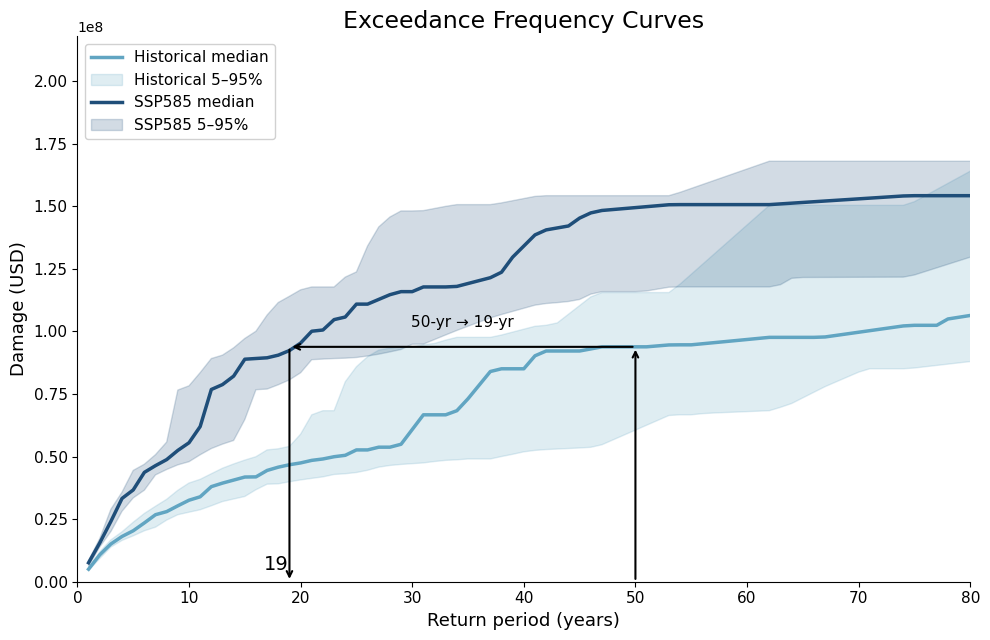

Results dictionary created: results
Historical 50-year event corresponds to approximately a 19-year event under SSP585.


In [49]:
#Colors
blue_dark = "#1f4e79"
blue_main = "#2a6f97"
blue_light = "#61a5c2"
blue_very_light = "#74a9cf"
grey = "#6c757d"

import numpy as np
import matplotlib.pyplot as plt
from climada.engine import Impact
from random import choices, seed

seed(10)


#Helper: derive years represented by an Impact object
def get_years_from_impact(imp):
    """
    Derive number of simulated years from CLIMADA frequency.
    Assumes constant event frequency within one Impact object.
    """
    return round(1 / imp.frequency[0])

#Bootstrap exceedance frequency curve
def bootstrap_member_efc(impacts, years_per_member, nreps=1000, sample_frac=1):
    """
    Bootstrap exceedance frequency curves from multiple Impact objects.

    Parameters
    ----------
    impacts : list
        List of CLIMADA Impact objects.
    years_per_member : int
        Number of simulated years per ensemble member.
    nreps : int
        Number of bootstrap repetitions.
    sample_frac : float
        Fraction of total years to sample.

    Returns
    -------
    rps : np.ndarray
        Return periods.
    q05, q50, q95 : np.ndarray
        5th, 50th, and 95th quantiles of bootstrapped damages.
    """
    nmods = len(impacts)
    nyrs_tot = years_per_member * nmods

    rp_max = int(round(nyrs_tot * sample_frac))
    rps = np.arange(1, rp_max)

    efcs = []

    for _ in range(nreps):
        events_all = []

        for imp in impacts:
            events = imp.at_event
            nev = len(events)

            yrs_imp = get_years_from_impact(imp)
            mem_imp = yrs_imp / years_per_member

            sub_sample_size = int(round(sample_frac * nev / mem_imp))
            sub_sample = choices(events.tolist(), k=sub_sample_size)

            events_all.append(sub_sample)

        events_stack = np.hstack(events_all)

        imp_boot = Impact()
        imp_boot.at_event = np.array(events_stack)
        imp_boot.frequency = np.repeat(1 / rp_max, len(events_stack))

        efc = imp_boot.calc_freq_curve(return_per=rps).impact
        efcs.append(efc)

    efcs = np.vstack(efcs)

    q05 = np.quantile(efcs, 0.05, axis=0)
    q50 = np.quantile(efcs, 0.50, axis=0)
    q95 = np.quantile(efcs, 0.95, axis=0)

    return rps, q05, q50, q95

#Run bootstrap for Historical and SSP585
historical_impacts = [imp_hist, imp_hist_2, imp_hist_4, imp_MPI_hist_1, imp_MPI_hist_2, imp_MPI_hist_4, imp_MRI_hist_1, imp_MRI_hist_2, imp_MRI_hist_4, imp_EARTH_hist_1, imp_EARTH_hist3, imp_EARTH_hist4]
ssp585_impacts = [imp_585_1, imp_585_2, imp_585_4, imp_MPI_SSP_2, imp_MPI_SSP_2, imp_MPI_SSP_4, imp_MRI_SSP_1, imp_MRI_SSP_2, imp_MRI_SSP_3, imp_EARTH_SSP_1, imp_EARTH_SSP_2, imp_EARTH_SSP_3]

years_hist = get_years_from_impact(imp_hist)
years_585 = get_years_from_impact(imp_585_1)

rps_hist, q05_hist, q50_hist, q95_hist = bootstrap_member_efc(
    historical_impacts,
    years_hist,
    nreps=1000,
    sample_frac=1
)

rps_585, q05_585, q50_585, q95_585 = bootstrap_member_efc(
    ssp585_impacts,
    years_585,
    nreps=1000,
    sample_frac=1
)

#Use common return period range
rp_common = min(len(rps_hist), len(rps_585))

rps = rps_hist[:rp_common]

q05_hist = q05_hist[:rp_common]
q50_hist = q50_hist[:rp_common]
q95_hist = q95_hist[:rp_common]

q05_585 = q05_585[:rp_common]
q50_585 = q50_585[:rp_common]
q95_585 = q95_585[:rp_common]

#Choose historical return period to highlight
medxp =   50
#historical return period to highlight

if medxp < 1 or medxp > len(rps):
    raise ValueError(f"medxp={medxp} is outside the available return period range 1-{len(rps)}")

#historical damage at chosen RP
medyp = q50_hist[medxp - 1]

#closest matching damage on SSP585 median curve
medxf_idx = np.argmin(np.abs(q50_585 - medyp))
medxf = rps[medxf_idx]
medyf = q50_585[medxf_idx]

#Plot exceedance frequency curves
fig, ax = plt.subplots(figsize=(10, 6.5))

#Historical
ax.plot(
    rps,
    q50_hist,
    color=blue_light,
    linewidth=2.5,
    label="Historical median"
)
ax.fill_between(
    rps,
    q05_hist,
    q95_hist,
    color=blue_light,
    alpha=0.20,
    label="Historical 5–95%"
)

#SSP585
ax.plot(
    rps,
    q50_585,
    color=blue_dark,
    linewidth=2.5,
    label="SSP585 median"
)
ax.fill_between(
    rps,
    q05_585,
    q95_585,
    color=blue_dark,
    alpha=0.20,
    label="SSP585 5–95%"
)


#Improve layout
#Optional: show only first part of RP axis for readability
xmax_plot = min(80, rps.max())
ax.set_xlim(0, xmax_plot)

#Let matplotlib determine y first, then use axis bottom for arrows
ax.relim()
ax.autoscale_view()

#Force bottom to 0 for cleaner damage interpretation
ymax_data = max(q95_hist.max(), q95_585.max()) * 1.05
ax.set_ylim(0, ymax_data)

ymin, ymax = ax.get_ylim()

#Clean style
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


#Add arrows (return period shift)
#Arrow 1: vertical up at historical RP
ax.annotate(
    "",
    xy=(medxp, medyp),
    xytext=(medxp, ymin),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
)

#Arrow 2: horizontal from historical RP to future RP
ax.annotate(
    "",
    xy=(medxf, medyp),
    xytext=(medxp, medyp),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
)

#Arrow 3: vertical down at future RP
ax.annotate(
    "",
    xy=(medxf, ymin),
    xytext=(medxf, medyp),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
)

#Label future RP near x-axis
label_y = ymin + 0.015 * (ymax - ymin)
ax.text(
    medxf - 2.3, 
    label_y,
    f"{int(medxf)}",
    color="black",
    fontsize=14,
    ha="left",  
    va="bottom"
)

ax.text(
    (medxp + medxf) / 2,
    medyp + 0.03 * (ymax - ymin),
    f"{medxp}-yr → {int(medxf)}-yr",
    fontsize=11,
    ha="center",
    va="bottom"
)


#Labels and legend
ax.set_xlabel("Return period (years)", fontsize=13)
ax.set_ylabel("Damage (USD)", fontsize=13)
ax.set_title("Exceedance Frequency Curves", fontsize=17)
ax.tick_params(axis="both", labelsize=11)
#ax.legend(frameon=False, fontsize=11, loc="lower right")
ax.legend(
    frameon=True,      
    fancybox=True,     
    framealpha=0.9,   
    fontsize=11,
    loc="upper left"
)

plt.tight_layout()


plt.savefig("/Users/anne-sophiesimons/Documents/Data thesis/return_periods_curve", dpi=300)
plt.show()

#Optional: save results
results = {
    "rps": rps,
    "hist_q05": q05_hist,
    "hist_q50": q50_hist,
    "hist_q95": q95_hist,
    "ssp585_q05": q05_585,
    "ssp585_q50": q50_585,
    "ssp585_q95": q95_585,
    "highlight_hist_rp": medxp,
    "matching_ssp585_rp": medxf,
    "highlight_damage": medyp
}

print("Results dictionary created: results")
print(f"Historical {medxp}-year event corresponds to approximately a {int(medxf)}-year event under SSP585.")